<a href="https://colab.research.google.com/github/aankit1729/spcx-vol-surface/blob/main/notebooks/01_surface_evolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — The implied volatility surface of a newly listed mega-cap

SpaceX (SPCX) listed in June 2026 with the largest first-day options volume on record.
This notebook builds its implied volatility surface from raw quotes and asks a simple
question: **does a stock with three months of price history get priced like a normal stock?**

SPY is the control — a mature, deeply liquid, heavily hedged underlying.

Run order: set `REPO` below, then Runtime → Run all.

In [1]:
REPO = "aankit1729/spcx-vol-surface"   # <-- your repo
TICKERS = ["SPCX", "SPY"]
RISK_FREE = 0.042

import sys, subprocess, os, shutil
shutil.rmtree("repo", ignore_errors=True)          # always start from a clean clone
subprocess.run(["git", "clone", "--depth", "1",
                f"https://github.com/{REPO}.git", "repo"], check=True)
sys.path.insert(0, "repo/src")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"], check=True)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from volsurface import bs, svi, clean, heston

# fail loudly if a stale module got cached
import inspect
assert "verbose" in inspect.signature(heston.calibrate).parameters, \
    "Stale heston.py — Runtime > Restart session, then run this cell again."

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
print("ready —", len(list(Path("repo/data/raw").glob("*/*.parquet"))), "snapshots in repo")

ready — 3 snapshots in repo


## 1. Load the most recent snapshot

Each snapshot is one trading day's full option chain. Early on you have one file per
ticker; as the collector accumulates, this cell picks the latest.

In [2]:
RAW = Path("repo/data/raw")
snaps = {}
for t in TICKERS:
    files = sorted((RAW / t).glob("*.parquet"))
    if not files:
        print(f"{t}: no snapshots yet"); continue
    snaps[t] = pd.read_parquet(files[-1])
    print(f"{t}: {len(files)} snapshot(s), latest {files[-1].stem}, "
          f"{len(snaps[t])} contracts, spot {snaps[t]['spot'].iloc[0]:.2f}")

snaps[TICKERS[0]].head(3)

SPCX: 1 snapshot(s), latest 2026-09-09, 2788 contracts, spot 153.47
SPY: 1 snapshot(s), latest 2026-09-09, 9602 contracts, spot 765.96


,contractSymbol,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,inTheMoney,lastTradeDate,cp,expiry,ticker,spot,snapshot_utc
0,SPCX260911C00010000,10.0,143.05,141.1,143.65,1.0,5,13.453127,True,2026-09-08 15:36:38+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00
1,SPCX260911C00015000,15.0,138.25,136.1,138.70,2.0,0,11.718753,True,2026-09-08 15:32:11+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00
2,SPCX260911C00020000,20.0,133.25,131.1,133.65,11.0,1,9.875004,True,2026-09-08 13:38:05+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00


## 2. Clean

What happens here matters more than the modelling, and it is the part interviewers probe.

- **Mid prices**, and drop any quote with no bid or a spread wider than 25% of mid.
  Zero-bid options are worthless-but-not-quite and their "prices" are noise.
- **Forward from put–call parity**, not `S·exp(rT)`. This absorbs dividends and, more
  importantly for SPCX, the borrow cost — which for a recent IPO with a lockup can be large.
- **OTM only**: calls above the forward, puts below. These are the liquid contracts, and
  it sidesteps early-exercise premium on American-style single stock options.
- **Recompute IV ourselves.** The `impliedVolatility` field from the data source is
  unreliable on thin strikes; we never use it.

In [3]:
cleaned = {}
for t, raw in snaps.items():
    c = clean.clean_chain(raw, r=RISK_FREE)
    cleaned[t] = c
    kept = 100 * len(c) / len(raw)
    print(f"{t}: {len(raw)} -> {len(c)} quotes ({kept:.0f}% kept), "
          f"{c['T'].nunique()} expiries, IV range {c['iv'].min():.1%}-{c['iv'].max():.1%}")

SPCX: 2788 -> 955 quotes (34% kept), 18 expiries, IV range 53.2%-116.1%
SPY: 9602 -> 4700 quotes (49% kept), 29 expiries, IV range 9.5%-84.3%


## 3. The smile, expiry by expiry

Log-moneyness `k = log(K/F)` on the x-axis so different expiries are comparable.
A downward slope is the equity skew: puts cost more than calls because crashes are
faster than rallies and because people buy protection.

Watch for whether SPCX's skew is *flatter* than SPY's — heavy retail call buying in a
hot new listing can bid up the right wing and partially offset the usual put skew.

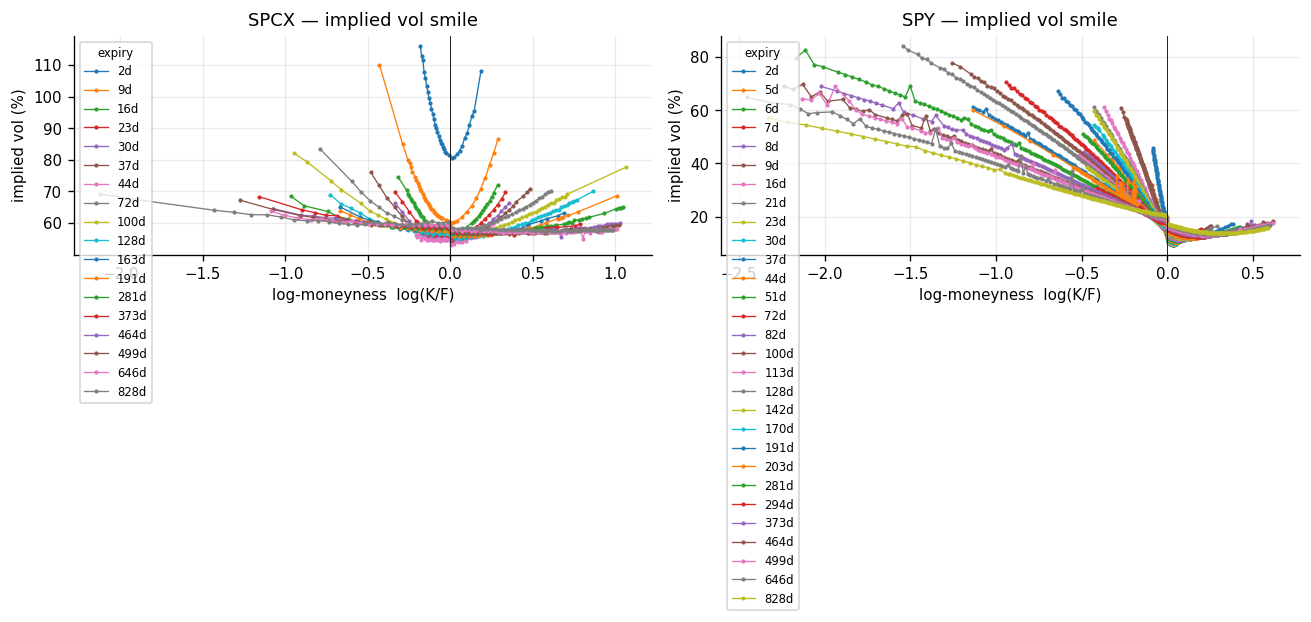

In [4]:
fig, axes = plt.subplots(1, len(cleaned), figsize=(5.5*len(cleaned), 4), squeeze=False)
for ax, (t, c) in zip(axes[0], cleaned.items()):
    for T, g in c.groupby("T"):
        ax.plot(g["k"], g["iv"]*100, ".-", ms=3, lw=.8, label=f"{T*365:.0f}d")
    ax.axvline(0, color="k", lw=.5)
    ax.set_title(f"{t} — implied vol smile"); ax.set_xlabel("log-moneyness  log(K/F)")
    ax.set_ylabel("implied vol (%)"); ax.legend(fontsize=7, title="expiry", title_fontsize=7)
plt.tight_layout(); plt.show()

## 4. Fit SVI to each slice

SVI (Gatheral) parameterises *total variance* `w(k) = σ²T` with five parameters:
level `a`, wing slope `b`, rotation `ρ`, translation `m`, and curvature `σ`.

Two arbitrage conditions get checked:
- **Butterfly** (Durrleman's `g(k) ≥ 0`): violated means the implied density goes
  negative somewhere — a call spread would have negative value.
- **Calendar**: total variance must not decrease with maturity, else you could buy
  the long option and sell the short one for a riskless profit.

A violation is not necessarily a bug in the fit. It can be stale quotes, a bad forward,
or — occasionally — a real dislocation. Investigate before you smooth it away.

In [5]:
fits = {}
for t, c in cleaned.items():
    rows = []
    for T, g in c.groupby("T"):
        w = 1.0 / np.maximum(g["ask"] - g["bid"], 1e-3)      # weight tight quotes more
        p = svi.fit_slice(g["k"].values, g["iv"].values, T, weights=w.values)
        rows.append(dict(T=T, days=T*365, params=p, n=len(g),
                         rmse_bp=svi.rmse_iv(g["k"].values, g["iv"].values, T, p)*1e4,
                         butterfly_ok=svi.butterfly_arbitrage_free(p),
                         atm_vol=float(svi.implied_vol(0.0, T, p))))
    f = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
    # calendar check between consecutive slices
    f["calendar_ok"] = [True] + [svi.calendar_arbitrage_free(f["params"][i-1], f["params"][i])
                                 for i in range(1, len(f))]
    fits[t] = f
    print(f"\n{t}")
    print(f[["days","n","atm_vol","rmse_bp","butterfly_ok","calendar_ok"]].round(4).to_string(index=False))


SPCX
 days  n  atm_vol  rmse_bp  butterfly_ok  calendar_ok
  2.0 35   0.8034  56.2936         False         True
  9.0 43   0.5988  56.4353         False         True
 16.0 54   0.5635  28.9061          True        False
 23.0 46   0.5498  23.6361          True        False
 30.0 46   0.5439  27.3070          True        False
 37.0 31   0.5407  24.8565          True        False
 44.0 37   0.5423  38.8159         False        False
 72.0 42   0.5749  29.0890          True        False
100.0 51   0.5635  46.6760          True        False
128.0 54   0.5561  34.5260          True         True
163.0 37   0.5632  46.8121          True         True
191.0 46   0.5639  41.1716          True        False
281.0 62   0.5683  47.7035          True         True
373.0 52   0.5748  45.2605          True         True
464.0 77   0.5795  41.4517          True         True
499.0 79   0.5756  43.4025          True        False
646.0 78   0.5823  46.1800          True         True
828.0 85   0.5871  45.

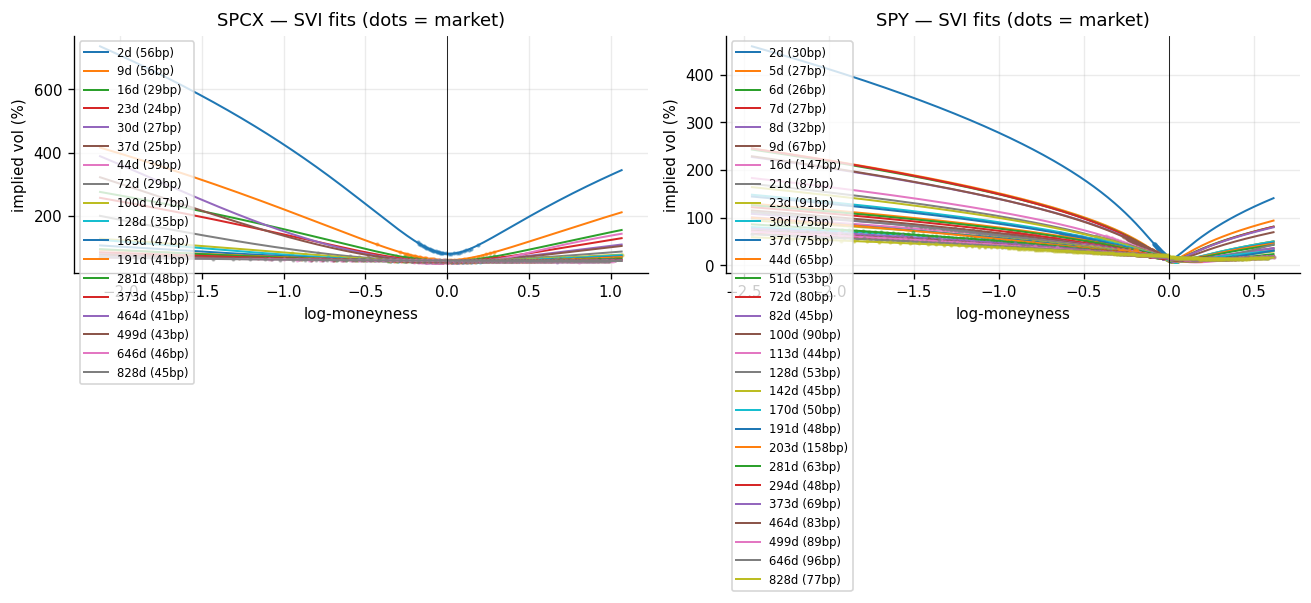

In [6]:
fig, axes = plt.subplots(1, len(cleaned), figsize=(5.5*len(cleaned), 4), squeeze=False)
for ax, (t, c) in zip(axes[0], cleaned.items()):
    kk = np.linspace(c["k"].min(), c["k"].max(), 300)
    for _, row in fits[t].iterrows():
        g = c[c["T"] == row["T"]]
        l, = ax.plot(kk, svi.implied_vol(kk, row["T"], row["params"])*100, lw=1.2,
                     label=f"{row['days']:.0f}d ({row['rmse_bp']:.0f}bp)")
        ax.plot(g["k"], g["iv"]*100, ".", ms=3, color=l.get_color(), alpha=.5)
    ax.axvline(0, color="k", lw=.5); ax.set_title(f"{t} — SVI fits (dots = market)")
    ax.set_xlabel("log-moneyness"); ax.set_ylabel("implied vol (%)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. Term structure and skew

Two numbers summarise a surface. **ATM vol by expiry** shows whether the market expects
near-term turbulence to fade (downward sloping) or build (upward). **Skew**, measured as
the 25-delta put vol minus the 25-delta call vol, shows the asymmetry.

For SPCX, look for humps in the term structure at expiries spanning known events —
lockup expiry and index inclusion both concentrate uncertainty on a date.

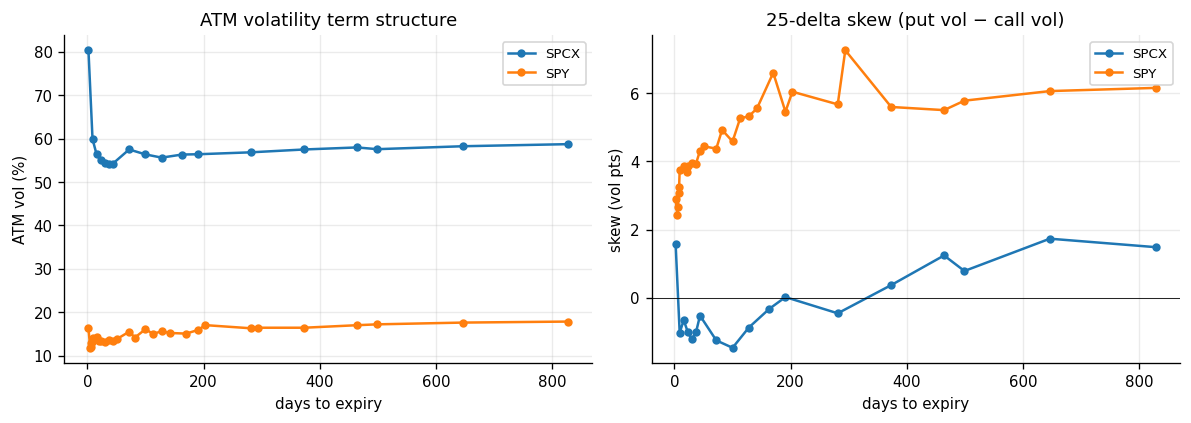

In [7]:
def delta_strike_vol(T, p, target_delta, cp, S, r):
    """IV at the strike whose BS delta equals target_delta, solved on the SVI slice."""
    kk = np.linspace(-1.2, 1.2, 2000)
    iv = svi.implied_vol(kk, T, p)
    F = S*np.exp(r*T); K = F*np.exp(kk)
    d = bs.delta(S, K, T, r, 0.0, iv, cp)
    i = np.argmin(np.abs(np.abs(d) - target_delta))
    return float(iv[i])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for t, c in cleaned.items():
    S = float(c["spot"].iloc[0]); f = fits[t]
    axes[0].plot(f["days"], f["atm_vol"]*100, "o-", ms=4, label=t)
    sk = [ (delta_strike_vol(r_.T, r_.params, .25, -1, S, RISK_FREE)
            - delta_strike_vol(r_.T, r_.params, .25, +1, S, RISK_FREE))*100
           for r_ in f.itertuples() ]
    axes[1].plot(f["days"], sk, "o-", ms=4, label=t)
axes[0].set_title("ATM volatility term structure"); axes[0].set_ylabel("ATM vol (%)")
axes[1].set_title("25-delta skew (put vol − call vol)"); axes[1].set_ylabel("skew (vol pts)")
axes[1].axhline(0, color="k", lw=.5)
for a in axes: a.set_xlabel("days to expiry"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Calibrate Heston to the whole surface

SVI fits each expiry independently — five parameters per slice, so a surface with six
expiries costs thirty parameters and says nothing about dynamics. Heston uses five
parameters for the *entire* surface and comes with a stochastic process, which is what
lets us compute a hedge ratio in notebook 04.

The fit will be visibly worse than SVI. That is the point: SVI describes, Heston explains.
Where Heston fails tells you which features of the surface a mean-reverting square-root
variance process cannot generate — typically the very short-dated smile, which needs jumps.

In [8]:
hfits = {}
for t, c in cleaned.items():
    S = float(c["spot"].iloc[0])
    chain = (c.drop(columns=["cp"])
               .rename(columns={"strike": "K", "cpi": "cp"})[["T", "K", "iv", "cp", "k"]])
    print(f"{t}: calibrating on {len(chain)} quotes...")
    p = heston.calibrate(chain, S, RISK_FREE, 0.0, verbose=True)
    rmse = heston.surface_rmse_bp(chain, S, RISK_FREE, 0.0, p)
    hfits[t] = p
    print(f"{t}:  v0={p.v0:.4f} (vol {np.sqrt(p.v0):.1%})  kappa={p.kappa:.2f}  "
          f"theta={p.theta:.4f} (vol {np.sqrt(p.theta):.1%})  xi={p.xi:.3f}  rho={p.rho:+.3f}")
    print(f"      Feller 2*kappa*theta - xi^2 = {p.feller():+.4f}"
          f"{'  (satisfied)' if p.feller() > 0 else '  (VIOLATED - variance can reach zero)'}")
    print(f"      surface RMSE = {rmse:.0f} bp of vol\n")

SPCX: calibrating on 955 quotes...
    eval   25  rmse   376.9 bp
    eval   50  rmse   320.1 bp
    eval   75  rmse   238.2 bp
    eval  100  rmse   204.5 bp
    eval  125  rmse   204.5 bp
    done: 132 evals, status 3 (`xtol` termination condition is satisfied.)
SPCX:  v0=0.3710 (vol 60.9%)  kappa=17.89  theta=0.3407 (vol 58.4%)  xi=5.000  rho=-0.027
      Feller 2*kappa*theta - xi^2 = -12.8110  (VIOLATED - variance can reach zero)
      surface RMSE = 608 bp of vol

SPY: calibrating on 4700 quotes...
    eval   25  rmse   493.1 bp
    eval   50  rmse   191.4 bp
    eval   75  rmse   186.9 bp
    eval  100  rmse   186.4 bp
    eval  125  rmse   186.2 bp
    eval  150  rmse   186.2 bp
    eval  175  rmse   186.2 bp
    eval  200  rmse   186.2 bp
    eval  225  rmse   186.2 bp
    eval  250  rmse   186.2 bp
    eval  275  rmse   186.1 bp
    eval  300  rmse   186.1 bp
    eval  325  rmse   186.1 bp
    eval  350  rmse   186.1 bp
    eval  375  rmse   186.1 bp
    eval  400  rmse   186.

## 7. What to write down

Fill these in from your own output — this becomes the README summary and the thing you
actually talk about in an interview:

1. Is SPCX's ATM vol level plausible for a mega-cap, or is it trading like a small cap?
2. Is the skew steeper or flatter than SPY's, and does the retail-call-buying story hold up?
3. Does the term structure have a bump at the lockup expiry or index inclusion date?
4. Where does Heston fail worst — short expiries, deep wings, or both?
5. Any arbitrage violations, and are they real or artefacts of thin quotes?

**Next:** `03_variance_risk_premium` once you have a few weeks of snapshots, since it
needs implied vol today compared against realised vol later.